#                                        NEXORA TECHNOLOGIES

# Sales Analysis and Business Intelligence

**Objective:** Analyze e-commerce transaction data to identify revenue trends, profitability drivers, customer behavior, product performance, and geographic opportunities, and translate the findings into actionable business recommendations.


## 1. Tools & Analytical Approach

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Workflow:**  
Raw Data → Data Quality Checks → Cleaning & Standardization → Data Transformation → Dataset Integration → KPI Analysis → Product/Customer/Geographic Analysis → Advanced EDA → Business Recommendations

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

## 3. Load Raw Dataset

In [4]:

customer = pd.read_csv("C:/Users/kaurm/Python/Projects/Nexora Technologies Sales Analysis and Business Intelligence/messy_customers.csv")
order_details = pd.read_csv("C:/Users/kaurm/Python/Projects/Nexora Technologies Sales Analysis and Business Intelligence/messy_order_items.csv")
orders = pd.read_csv("C:/Users/kaurm/Python/Projects/Nexora Technologies Sales Analysis and Business Intelligence/messy_orders.csv")
products = pd.read_csv("C:/Users/kaurm/Python/Projects/Nexora Technologies Sales Analysis and Business Intelligence/messy_products.csv")

print("Customers:", customer.shape)
print("Order items:", order_details.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)

Customers: (520, 4)
Order items: (2050, 5)
Orders: (1240, 4)
Products: (90, 4)


## 4. Data Cleaning

### 4.1 Remove exact duplicate rows


In [ ]:
customer = customer.drop_duplicates().copy()
orders = orders.drop_duplicates().copy()
order_details = order_details.drop_duplicates().copy()
products = products.drop_duplicates().copy()

### 4.2 Clean customer fields


In [ ]:
customer["customer_name"] = customer["customer_name"].fillna("Unknown")
customer["city"] = customer["city"].fillna("Unknown").astype(str).str.strip()

city_map = {
    "bengaluru": "Bangalore",
    "bengalore": "Bangalore",
    "bangalore": "Bangalore",
    "delhi": "Delhi",
    "mumbai": "Mumbai"
}

customer["city"] = (
    customer["city"]
    .str.lower()
    .replace(city_map)
    .str.title()
)


In [ ]:
customer["customer_name"] = customer["customer_name"].fillna("Unknown")

customer["city"] = (
    customer["city"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.title()
)

### 4.4 Convert date columns


In [ ]:
customer["signup_date"] = pd.to_datetime(
    customer["signup_date"],
    format="mixed",
    errors="coerce"
)

orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    format="mixed",
    errors="coerce"
)

print("Invalid signup dates:", customer["signup_date"].isna().sum())
print("Invalid order dates:", orders["order_date"].isna().sum())


Invalid signup dates: 0
Invalid order dates: 0


### 4.5 Standardize payment methods

In [ ]:
orders["payment_method"] = (
    orders["payment_method"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "cash on delivery": "cash",
        "cod": "cash"
    })
    .str.title()
)

print(orders["payment_method"].value_counts(dropna=False))


payment_method
Upi            313
Credit Card    309
Cash           303
Unknown        141
Debit Card     134
Name: count, dtype: int64


### 4.6 Standardize product categories

In [ ]:
products["category"] = (
    products["category"]
    .fillna("Unknown")
    .str.strip()
    .str.title()
    .replace({
        "Smart Phone": "Smartphone",
        "Accessory": "Accessories"
    })
)

print(products["category"].value_counts(dropna=False))

category
Smartphone     24
Accessories    20
Tablet         19
Laptop         17
Name: count, dtype: int64


### 4.7 Handle missing product base prices



In [ ]:
products["base_price"] = pd.to_numeric(products["base_price"], errors="coerce")

products["base_price"] = products["base_price"].fillna(
    products.groupby("category")["base_price"].transform("median")
)

print("Remaining missing product base prices:", products["base_price"].isna().sum())

Remaining missing product base prices: 0


### 4.8 Handling Missing Values and Invalid Records



In [ ]:
order_details = order_details[order_details["quantity"] > 0].copy()
quantity_median = order_details["quantity"].median()
order_details["quantity"] = order_details["quantity"].fillna(quantity_median).round()
base_price_map = products.set_index("product_id")["base_price"]
mapped_base_price = order_details["product_id"].map(base_price_map)
order_details["unit_price"] = order_details["unit_price"].fillna(mapped_base_price)

print("Remaining missing values in order items:")
print(order_details[["product_id", "quantity", "unit_price"]].isnull().sum())

Remaining missing values in order items:
product_id    0
quantity      0
unit_price    0
dtype: int64


### 4.9 Final data-quality validation

In [ ]:
print("Customers duplicates:", customer.duplicated().sum())
print("Orders duplicates:", orders.duplicated().sum())
print("Order Items duplicates:", order_details.duplicated().sum())
print("Products duplicates:", products.duplicated().sum())

print("\nMissing values after cleaning:")
for name, df in {
    "Customers": customer,
    "Orders": orders,
    "Order Items": order_details,
    "Products": products
}.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing}")

print("\nOrders missing values by column:")
print(orders.isnull().sum())


Customers duplicates: 0
Orders duplicates: 0
Order Items duplicates: 0
Products duplicates: 0

Missing values after cleaning:
Customers: 0
Orders: 0
Order Items: 0
Products: 0

Orders missing values by column:
order_id          0
customer_id       0
order_date        0
payment_method    0
dtype: int64


## 5. Data Transformation & Dataset Integration

In [ ]:
customer["signup_year"] = customer["signup_date"].dt.year
customer["signup_month_num"] = customer["signup_date"].dt.month
customer["signup_month"] = customer["signup_date"].dt.month_name()
customer["signup_quarter"] = customer["signup_date"].dt.quarter

orders["order_year"] = orders["order_date"].dt.year
orders["order_month_num"] = orders["order_date"].dt.month
orders["order_month"] = orders["order_date"].dt.month_name()
orders["order_quarter"] = orders["order_date"].dt.quarter

sales = (
    orders
    .merge(order_details, on="order_id", how="inner", validate="one_to_many")
    .merge(customer, on="customer_id", how="left", validate="many_to_one")
    .merge(products, on="product_id", how="left", validate="many_to_one")
)

sales["sales_amount"] = sales["quantity"] * sales["unit_price"]
sales["profit"] = (sales["unit_price"] - sales["base_price"]) * sales["quantity"]
sales["profit_margin"] = np.where(
    sales["sales_amount"] != 0,
    sales["profit"] / sales["sales_amount"] * 100,
    np.nan
)

print("Analytical dataset shape:", sales.shape)
sales.head()

Analytical dataset shape: (1359, 25)


,order_id,customer_id,order_date,payment_method,order_year,order_month_num,order_month,order_quarter,order_item_id,product_id,quantity,unit_price,customer_name,city,signup_date,signup_year,signup_month_num,signup_month,signup_quarter,product_name,category,base_price,sales_amount,profit,profit_margin
0,O00001,C0058,2024-09-05,Cash,2024,9,September,3,844,P064,1.00,"25,696.00",Customer_58,Bangalore,2024-02-13,2024,2,February,1,Lenovo IdeaPad,Accessories,"81,129.00","25,696.00","-55,433.00",-215.73
1,O00002,C0410,2024-02-01,Upi,2024,2,February,1,892,P020,4.00,"51,735.00",Customer_410,Delhi,2024-03-20,2024,3,March,1,Dell Inspiron,Smartphone,"51,735.00","206,940.00",0.00,0.00
2,O00004,C0272,2024-02-25,Debit Card,2024,2,February,1,217,P005,1.00,"43,027.00",Customer_272,Kolkata,2023-06-15,2023,6,June,2,OnePlus,Tablet,"43,027.00","43,027.00",0.00,0.00
3,O00004,C0272,2024-02-25,Debit Card,2024,2,February,1,548,P017,1.00,"51,735.00",Customer_272,Kolkata,2023-06-15,2023,6,June,2,Keyboard,Smartphone,"51,735.00","51,735.00",0.00,0.00
4,O00005,C0411,2025-04-26,Credit Card,2025,4,April,2,480,P023,4.00,"40,971.00",Customer_411,Bangalore,2023-04-27,2023,4,April,2,Lenovo Tab,Tablet,"43,027.00","163,884.00","-8,224.00",-5.02


## 6. Executive KPI Dashboard



In [ ]:
total_sales = sales["sales_amount"].sum()
total_profit = sales["profit"].sum()
total_orders = sales["order_id"].nunique()
total_customers = sales["customer_id"].nunique()

kpis = pd.Series({
    "Total Sales": total_sales,
    "Total Profit": total_profit,
    "Total Orders": total_orders,
    "Total Customers": total_customers,
})

print(kpis)

Total Sales       152,903,055.50
Total Profit       -1,725,258.50
Total Orders              805.00
Total Customers           397.00
dtype: float64


# 7. Sales Performance Analysis

## 7.1 Monthly Sales Trend


In [ ]:
month_order = list(range(1, 13))
monthly_sales = (
    sales.groupby("order_month_num")["sales_amount"]
    .sum()
    .reindex(month_order)
)
print("Peak month:", monthly_sales.idxmax(), "Sales:", f"₹{monthly_sales.max():,.0f}")


Peak month: 1 Sales: ₹21,113,937


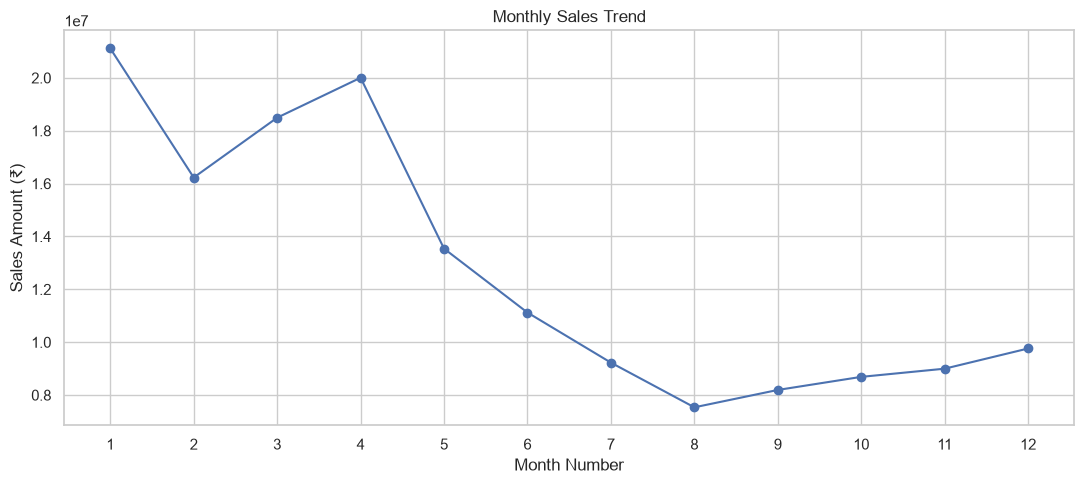

Peak month: 1 Sales: ₹21,113,937


In [ ]:
plt.figure(figsize=(11, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month Number")
plt.ylabel("Sales Amount (₹)")
plt.xticks(month_order)
plt.tight_layout()
plt.show()

print("Peak month:", monthly_sales.idxmax(), "Sales:", f"₹{monthly_sales.max():,.0f}")

## 7.2 Peak Sales Month

In [ ]:
monthly_sales = (
    sales.groupby(
        sales['order_date'].dt.month_name()
    )['sales_amount']
    .sum()
)


peak_month = monthly_sales.idxmax()

peak_sales = monthly_sales.max()

print("Peak Sales Month:", peak_month)
print("Sales:", peak_sales)

Peak Sales Month: January
Sales: 21113937.0


## 7.3 Category-wise Sales & Revenue Contribution


In [ ]:
category_sales = sales.groupby("category")["sales_amount"].sum().sort_values(ascending=False)
print(category_sales)




category
Smartphone    51,643,695.00
Accessories   37,639,203.00
Tablet        34,944,107.00
Laptop        28,676,050.50
Name: sales_amount, dtype: float64


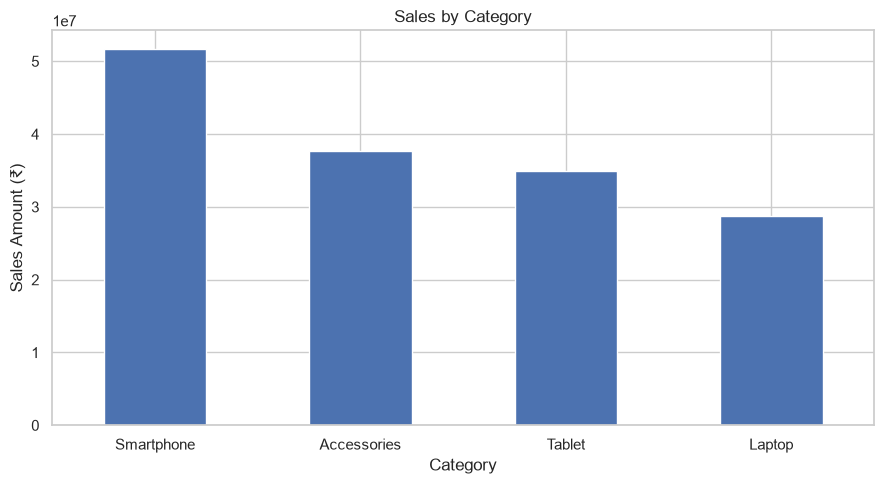

category
Smartphone    51,643,695.00
Accessories   37,639,203.00
Tablet        34,944,107.00
Laptop        28,676,050.50
Name: sales_amount, dtype: float64


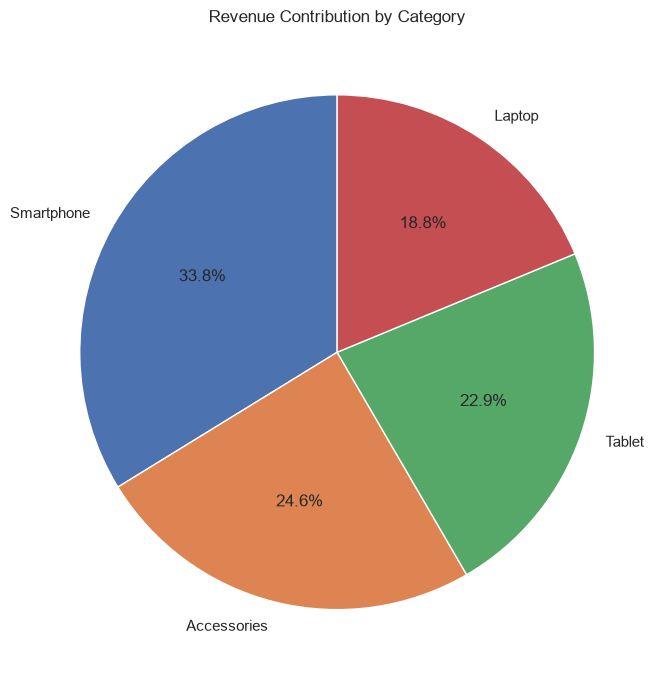

category
Smartphone    33.78
Accessories   24.62
Tablet        22.85
Laptop        18.75
Name: sales_amount, dtype: float64


In [ ]:
plt.figure(figsize=(9, 5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(category_sales)

category_share = category_sales / category_sales.sum() * 100

plt.figure(figsize=(7, 7))
plt.pie(category_share, labels=category_share.index, autopct="%1.1f%%", startangle=90)
plt.title("Revenue Contribution by Category")
plt.tight_layout()
plt.show()

print(category_share)

# 8. Product Performance & Profitability

## 8.1 Top 10 Products by Sales


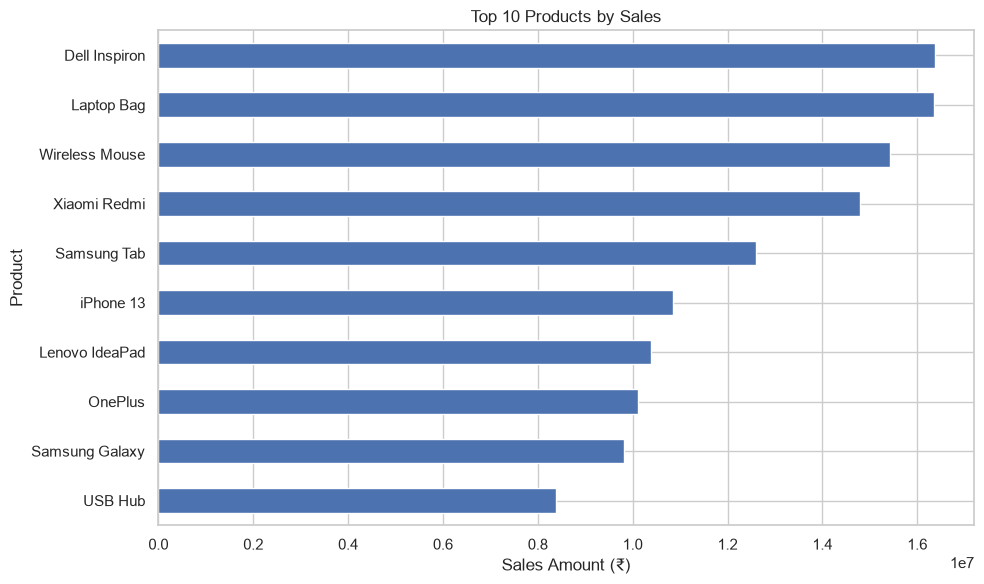

product_name
Dell Inspiron    16,378,302.50
Laptop Bag       16,359,507.50
Wireless Mouse   15,422,146.00
Xiaomi Redmi     14,790,978.50
Samsung Tab      12,591,269.00
iPhone 13        10,844,140.00
Lenovo IdeaPad   10,379,879.00
OnePlus          10,119,365.00
Samsung Galaxy    9,814,531.00
USB Hub           8,374,070.50
Name: sales_amount, dtype: float64


In [ ]:
top_products = (
    sales.groupby("product_name")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)


plt.figure(figsize=(10, 6))
top_products.plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales Amount (₹)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

print(top_products.sort_values(ascending=False))

## 8.2 Bottom 10 Products by Sales


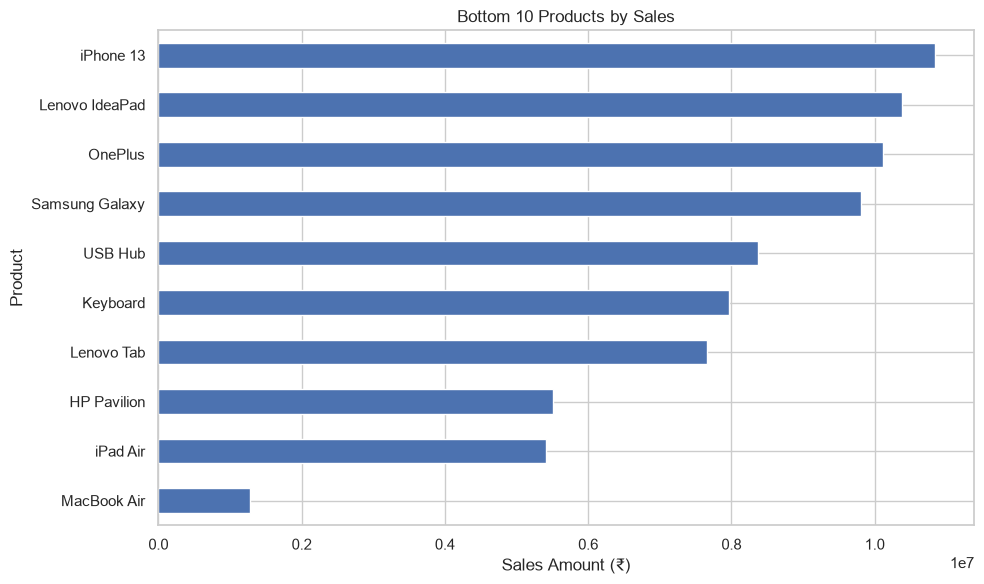

product_name
MacBook Air       1,278,303.00
iPad Air          5,412,059.00
HP Pavilion       5,508,235.50
Lenovo Tab        7,662,354.00
Keyboard          7,967,915.00
USB Hub           8,374,070.50
Samsung Galaxy    9,814,531.00
OnePlus          10,119,365.00
Lenovo IdeaPad   10,379,879.00
iPhone 13        10,844,140.00
Name: sales_amount, dtype: float64


In [ ]:
bottom_products = (
    sales.groupby("product_name")["sales_amount"]
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10, 6))
bottom_products.plot(kind="barh")
plt.title("Bottom 10 Products by Sales")
plt.xlabel("Sales Amount (₹)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

print(bottom_products)

# 9. Customer Analysis

## 9.1 Top Customers


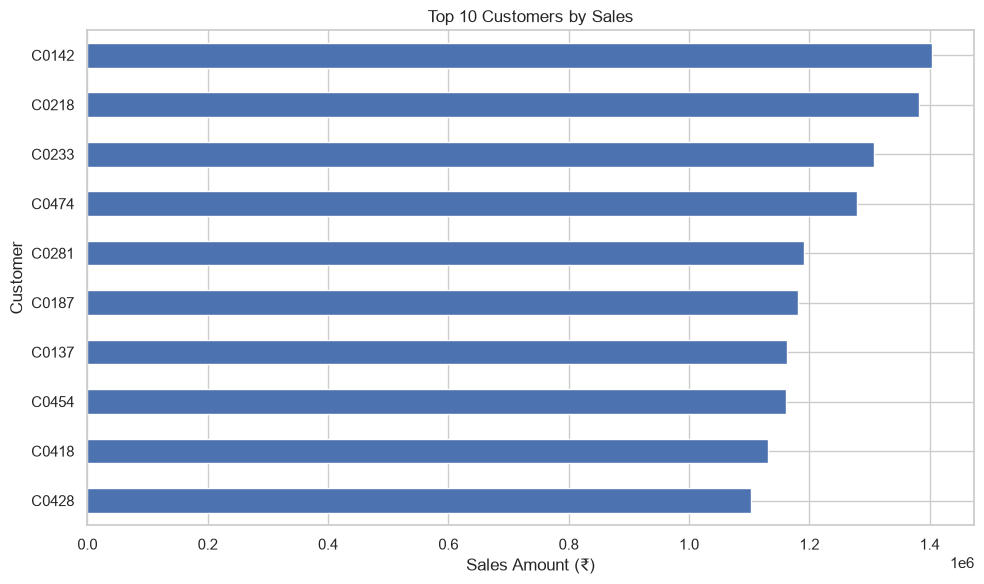

customer_id
C0142   1,403,565.50
C0218   1,381,521.00
C0233   1,307,125.00
C0474   1,278,563.00
C0281   1,190,540.00
C0187   1,181,148.00
C0137   1,162,960.00
C0454   1,160,907.00
C0418   1,130,739.00
C0428   1,102,428.50
Name: sales_amount, dtype: float64


In [ ]:
top_customers = (
    sales.groupby("customer_id")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)



plt.figure(figsize=(10, 6))
top_customers.plot(kind="barh")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales Amount (₹)")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

print(top_customers.sort_values(ascending=False))


## 9.2 Customer Segmentation by Spend


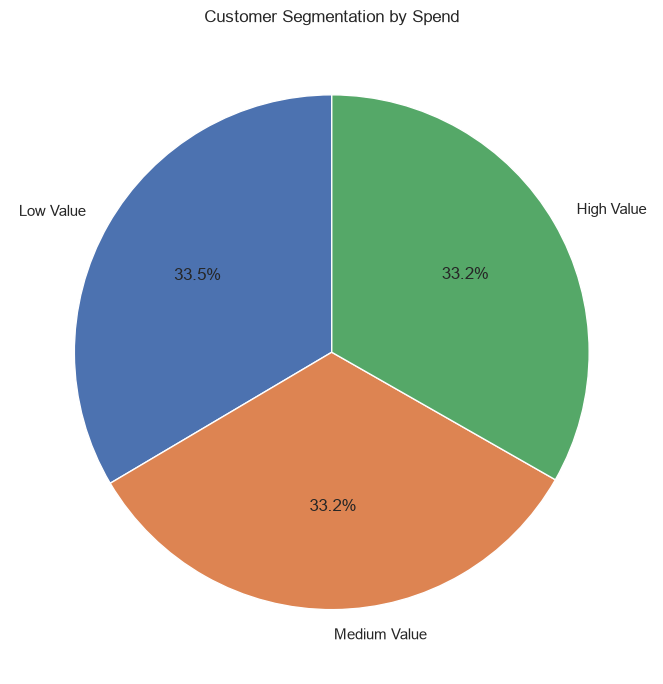

sales_amount
Low Value       133
Medium Value    132
High Value      132
Name: count, dtype: int64


In [ ]:
customer_value = sales.groupby("customer_id")["sales_amount"].sum()
customer_segment = pd.qcut(
    customer_value.rank(method="first"),
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)
segment_counts = customer_segment.value_counts().reindex(
    ["Low Value", "Medium Value", "High Value"]
)


plt.figure(figsize=(7, 7))
plt.pie(segment_counts, labels=segment_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Customer Segmentation by Spend")
plt.tight_layout()
plt.show()

print(segment_counts)

## 9.3 Repeat vs One-Time Customers


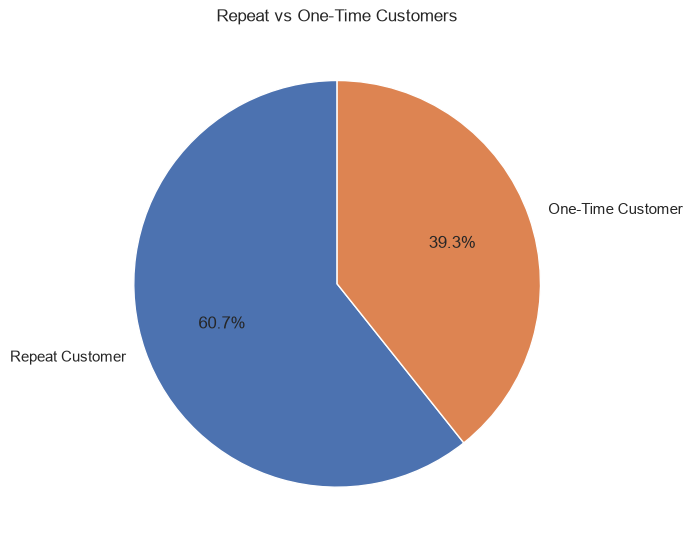

Repeat Customer      241
One-Time Customer    156
Name: count, dtype: int64


In [ ]:
customer_orders = sales.groupby("customer_id")["order_id"].nunique()
customer_type = np.where(
    customer_orders > 1,
    "Repeat Customer",
    "One-Time Customer"
)
customer_type = pd.Series(customer_type, index=customer_orders.index)
repeat_counts = customer_type.value_counts()


plt.figure(figsize=(7, 7))
plt.pie(repeat_counts, labels=repeat_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Repeat vs One-Time Customers")
plt.tight_layout()
plt.show()

print(repeat_counts)

# 10. Geographic Analysis

## 10.1 Sales by City


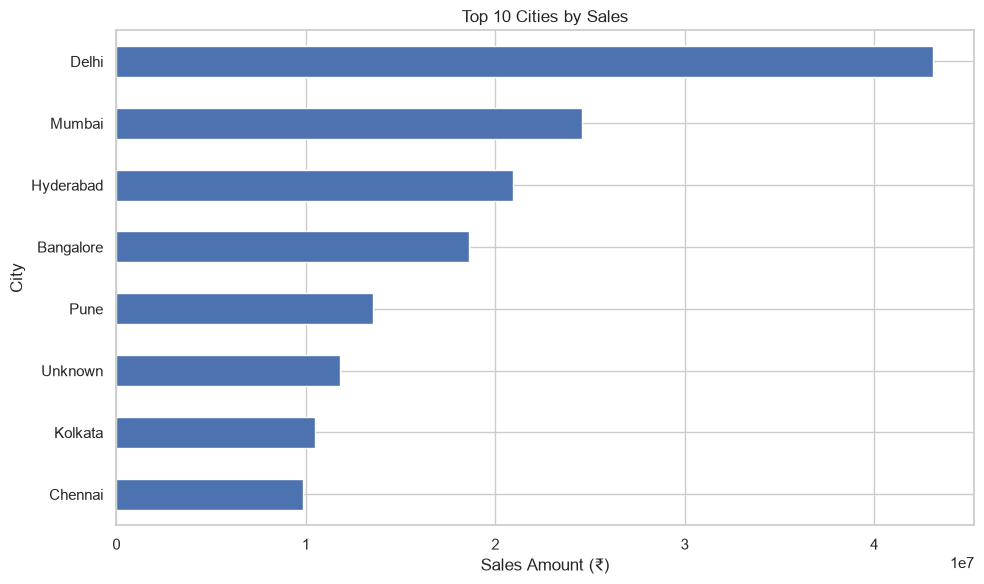

city
Delhi       43,114,449.50
Mumbai      24,584,164.50
Hyderabad   20,911,148.00
Bangalore   18,605,204.00
Pune        13,531,244.00
Unknown     11,800,454.50
Kolkata     10,496,270.00
Chennai      9,860,121.00
Name: sales_amount, dtype: float64


In [ ]:
city_sales = (
    sales.groupby("city")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

top_city_sales = city_sales.head(10).sort_values()

plt.figure(figsize=(10, 6))
top_city_sales.plot(kind="barh")
plt.title("Top 10 Cities by Sales")
plt.xlabel("Sales Amount (₹)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

print(city_sales.head(10))

## 10.2 Customer Distribution by City


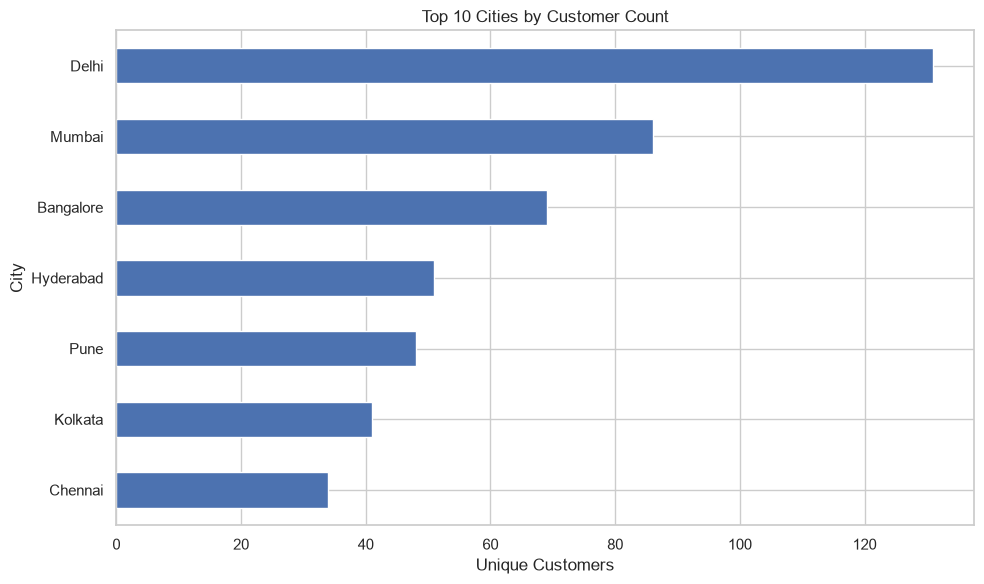

city
Delhi        131
Mumbai        86
Bangalore     69
Hyderabad     51
Pune          48
Kolkata       41
Chennai       34
Name: customer_id, dtype: int64


In [ ]:
customers_by_city = (customer[customer["city"] != "Unknown"].groupby("city")["customer_id"].nunique().sort_values(ascending=False))

plt.figure(figsize=(10, 6))
customers_by_city.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Customer Count")
plt.xlabel("Unique Customers")
plt.ylabel("City")
plt.tight_layout()
plt.show()

print(customers_by_city.head(10))

# 11. Customer Acquisition

## 11.1 Monthly Customer Signup Trend


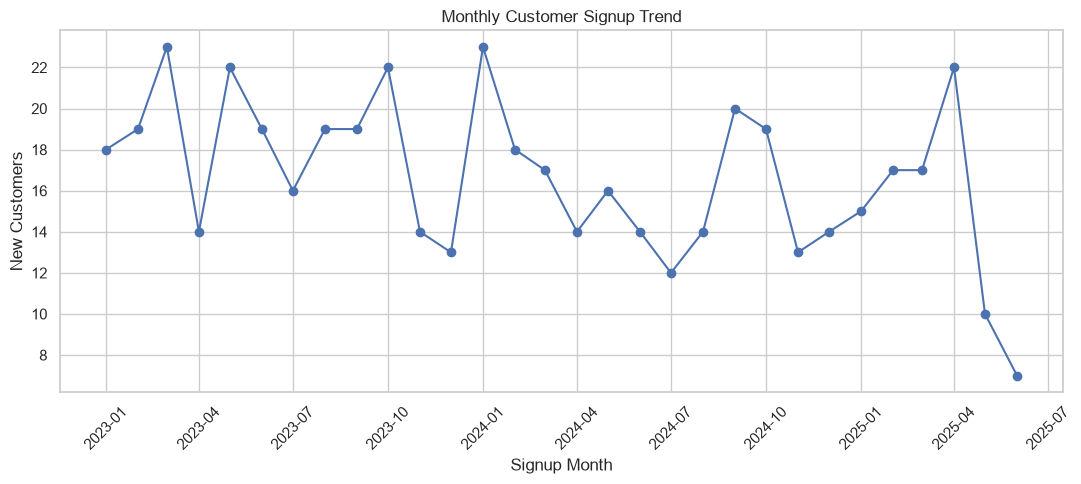

signup_date
2023-01-01    18
2023-02-01    19
2023-03-01    23
2023-04-01    14
2023-05-01    22
2023-06-01    19
2023-07-01    16
2023-08-01    19
2023-09-01    19
2023-10-01    22
2023-11-01    14
2023-12-01    13
2024-01-01    23
2024-02-01    18
2024-03-01    17
2024-04-01    14
2024-05-01    16
2024-06-01    14
2024-07-01    12
2024-08-01    14
2024-09-01    20
2024-10-01    19
2024-11-01    13
2024-12-01    14
2025-01-01    15
2025-02-01    17
2025-03-01    17
2025-04-01    22
2025-05-01    10
2025-06-01     7
Freq: MS, Name: customer_id, dtype: int64


In [ ]:
signup_monthly = (
    customer.dropna(subset=["signup_date"])
    .set_index("signup_date")
    .resample("MS")["customer_id"]
    .nunique()
)


plt.figure(figsize=(11, 5))
plt.plot(signup_monthly.index, signup_monthly.values, marker="o")
plt.title("Monthly Customer Signup Trend")
plt.xlabel("Signup Month")
plt.ylabel("New Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(signup_monthly)

# 12. Advanced EDA

## 12.1 Profitability Analysis

**Sale vs Profit**

In [ ]:
total_sales = sales["sales_amount"].sum()
total_profit = sales["profit"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 152903055.5
Total Profit: -1725258.5


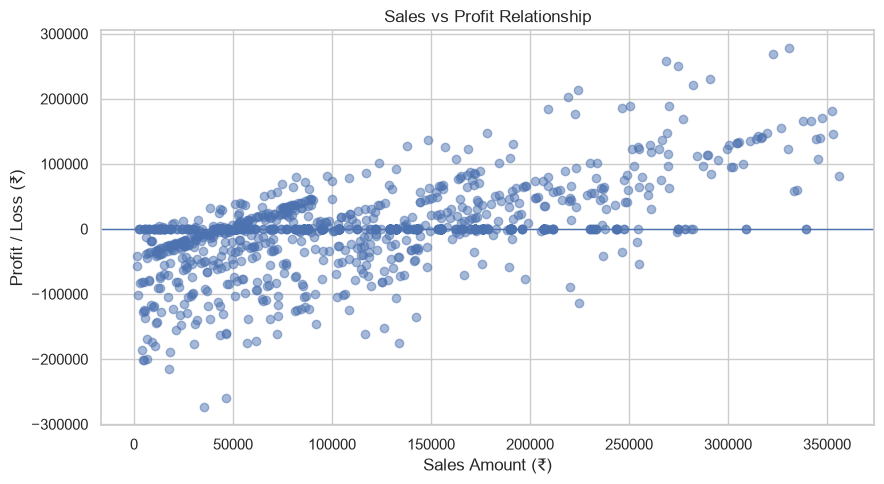

In [ ]:
plt.figure(figsize=(9, 5))
plt.scatter(sales["sales_amount"], sales["profit"], alpha=0.5)
plt.axhline(0, linewidth=1)
plt.title("Sales vs Profit Relationship")
plt.xlabel("Sales Amount (₹)")
plt.ylabel("Profit / Loss (₹)")
plt.tight_layout()
plt.show()

## 12.2 Profit Margin Analysis

**Overall Margin**

In [ ]:
overall_profit_margin = (
    total_profit / total_sales
) * 100

print("Overall Profit Margin:", round(overall_profit_margin, 2), "%")

Overall Profit Margin: -1.13 %


**Category-level Margin**

In [ ]:
category_profitability = sales.groupby("category").agg(
    total_sales=("sales_amount", "sum"),
    total_profit=("profit", "sum")
)

category_profitability["profit_margin"] = (
    category_profitability["total_profit"]
    / category_profitability["total_sales"]
) * 100

highest_margin_category = category_profitability["profit_margin"].idxmax()
lowest_margin_category = category_profitability["profit_margin"].idxmin()



## 12.2 Correlation Analysis


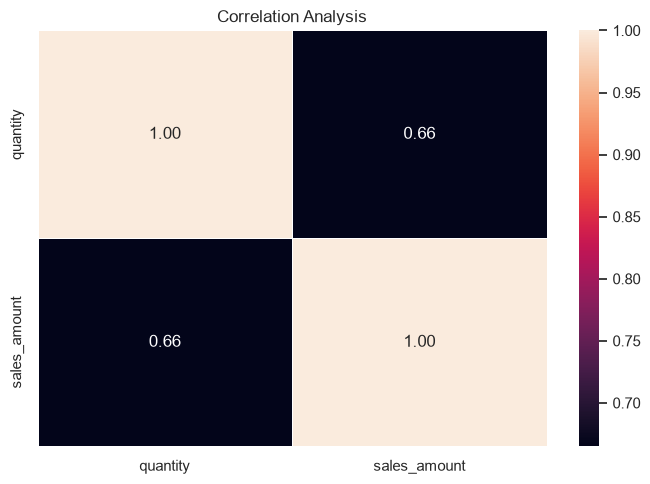

              quantity  sales_amount
quantity          1.00          0.66
sales_amount      0.66          1.00


In [ ]:
corr = sales[["quantity", "sales_amount"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Analysis")
plt.tight_layout()
plt.show()

print(corr)

## 12.3 Sales Amount Outlier Analysis


C:\Users\kaurm\AppData\Local\Temp\ipykernel_1956\3589474915.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(sales["sales_amount"].dropna(), vert=False)


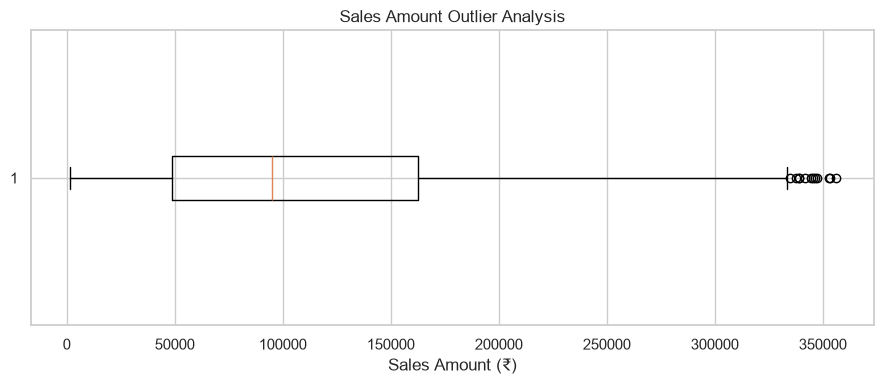

In [ ]:
plt.figure(figsize=(9, 4))
plt.boxplot(sales["sales_amount"].dropna(), vert=False)
plt.title("Sales Amount Outlier Analysis")
plt.xlabel("Sales Amount (₹)")
plt.tight_layout()
plt.show()

# 13. Key Business Findings

Based on the current notebook outputs:

1. **Revenue:** Total sales are approximately **₹180.39M** across **890 orders**.
2. **Profitability:** The business has an overall **loss of ₹591K** and a **-0.33% profit margin**.
3. **Peak period:** **January** is the highest-sales month, at approximately **₹23.93M**.
4. **Category profitability:** **Tablet** is the strongest profit contributor, while **Smartphone** has the largest category-level loss.
5. **Basket size:** Average quantity per order is approximately **4.49 items**.
6. **Profitability risk:** Loss-making products and transactions should be reviewed before pursuing aggressive revenue growth.

> The remaining product, customer, city, and signup findings should be written from the actual chart outputs rather than hard-coded assumptions.

# 14. Business Recommendations

### 1. Prioritize profitable growth
Revenue is high but overall profit is negative. Focus on margin improvement, not sales volume alone.

### 2. Review loss-making products
Investigate selling price, base cost, discounts, and supplier economics for products with negative profit.

### 3. Strengthen profitable categories
Tablet and Accessories currently contribute positive category-level profit. Protect availability and evaluate opportunities to scale them sustainably.

### 4. Improve customer retention
Increase repeat purchases through loyalty initiatives, personalized offers, and product recommendations.

### 5. Optimize inventory by demand
Use monthly and product-level sales patterns to prioritize stock for high-demand products.

### 6. Localize geographic strategy
Use city-level revenue and customer concentration to decide where to focus marketing and inventory investment.

### 7. Increase basket size
With an average of about 4.49 items per order, bundles and cross-selling can be tested to increase order value.

### 8. Use acquisition trends
Replicate acquisition strategies that coincide with strong monthly signup periods and investigate periods of weak acquisition.

# 15. Conclusion

This analysis combines data cleaning, data integration, KPI reporting, sales trend analysis, product and category profitability, customer behavior, geographic performance, acquisition trends, and advanced EDA.

The key business takeaway is that **strong revenue does not automatically translate into profit**. The largest opportunity is to improve pricing and cost economics in loss-making areas while retaining high-value customers and scaling profitable products/categories.